# Week 1: 쇼핑 에이전트 ReAct Graph

**도메인:** 쇼핑 추천 에이전트 (1주차는 mock 데이터로 시작, 3주차부터 실제 데이터로 교체 예정)

**목표:** `create_agent` 같은 helper 없이 `StateGraph`로 ReAct 루프를 직접 구성한다.

## 그래프 흐름
```
START → agent → (도구 필요?) ──아니오──→ final → END
                    │
                   예
                    ↓
                  tools ──→ agent (다시 판단)
```

- `agent` 노드: 모델이 도구 사용 여부를 판단
- `tools` 노드: 도구 실제 실행
- `final` 노드: 도구 결과 모아서 Pydantic 스키마로 최종 응답 생성

## 0. 환경 설정

필요한 패키지가 이미 설치되어 있다면 이 셀은 건너뛰어도 됩니다.

In [ ]:
# !pip install langgraph langchain langchain-openai langchain-anthropic pydantic python-dotenv

In [1]:
from dotenv import load_dotenv
import os

load_dotenv("../.env", override=True)

# LangSmith 추적 끄기 (필요하면 켜도 됨)
os.environ["LANGSMITH_TRACING"] = "false"
os.environ["LANGSMITH_TRACING_V2"] = "false"

## 1. 도메인 도구 3개 만들기

1주차에는 mock 데이터로 충분합니다. 핵심은 "모델이 도구를 호출할 수 있는 형태로 정의하는 것".

`@tool` 데코레이터를 붙이면 LangChain이 함수 시그니처와 docstring을 보고 모델에게 이 도구를 어떻게 쓰는지 자동으로 알려줍니다.

**docstring이 곧 도구 설명서**라서 모델이 도구 선택할 때 이걸 보고 판단합니다. 명확하게 쓰는 게 중요해요.

In [2]:
from langchain_core.tools import tool

# Mock 상품 DB
MOCK_PRODUCTS = {
    "P001": {"name": "아디다스 삼바 OG 블랙", "price": 139000, "category": "sneakers", "sizes": [240, 250, 260, 270, 280], "stock": 12},
    "P002": {"name": "나이키 에어포스1 화이트", "price": 129000, "category": "sneakers", "sizes": [240, 250, 260, 270], "stock": 5},
    "P003": {"name": "유니클로 에어리즘 티셔츠", "price": 19900, "category": "top", "sizes": ["S", "M", "L", "XL"], "stock": 50},
    "P004": {"name": "무신사 스탠다드 와이드 슬랙스", "price": 39900, "category": "bottom", "sizes": [28, 30, 32, 34], "stock": 0},
    "P005": {"name": "컨버스 척테일러 70 블랙", "price": 119000, "category": "sneakers", "sizes": [240, 250, 260, 270, 280], "stock": 8},
}

# Mock 사이즈 가이드
SIZE_GUIDES = {
    "sneakers": "운동화는 평소 발 길이(mm) + 5~10mm 권장. 아디다스는 살짝 크게, 컨버스는 정사이즈.",
    "top": "상의는 어깨너비 기준. S(42), M(44), L(46), XL(48). 오버핏 원하면 한 사이즈 업.",
    "bottom": "하의는 허리 인치(in) 기준. 무신사 와이드핏은 정사이즈 추천.",
}


@tool
def search_products(query: str) -> list[dict]:
    """상품명이나 카테고리로 상품을 검색합니다.
    
    Args:
        query: 검색어 (예: '운동화', '삼바', '티셔츠')
    
    Returns:
        매칭된 상품 리스트 (id, name, price, stock 포함)
    """
    q = query.lower()
    results = []
    for pid, p in MOCK_PRODUCTS.items():
        if q in p["name"].lower() or q in p["category"]:
            results.append({"id": pid, "name": p["name"], "price": p["price"], "stock": p["stock"]})
    return results if results else [{"message": f"'{query}'에 대한 검색 결과가 없습니다."}]


@tool
def get_product_detail(product_id: str) -> dict:
    """상품 ID로 상세 정보를 조회합니다 (가격, 재고, 사이즈 등).
    
    Args:
        product_id: 상품 ID (예: 'P001')
    
    Returns:
        상품 상세 정보 dict
    """
    if product_id not in MOCK_PRODUCTS:
        return {"error": f"상품 {product_id}를 찾을 수 없습니다."}
    return {"id": product_id, **MOCK_PRODUCTS[product_id]}


@tool
def get_size_guide(category: str) -> str:
    """카테고리별 사이즈 가이드를 반환합니다.
    
    Args:
        category: 'sneakers', 'top', 'bottom' 중 하나
    
    Returns:
        사이즈 가이드 텍스트
    """
    return SIZE_GUIDES.get(category, f"'{category}' 카테고리는 가이드가 없습니다.")


tools = [search_products, get_product_detail, get_size_guide]
print(f"도구 {len(tools)}개 등록 완료:", [t.name for t in tools])

도구 3개 등록 완료: ['search_products', 'get_product_detail', 'get_size_guide']


## 2. 도구 동작 빠르게 확인

그래프 만들기 전에 도구가 잘 도는지만 보고 갑시다.

In [3]:
# .invoke()는 도구를 직접 실행하는 방법
print(search_products.invoke({"query": "운동화"}))
print(get_product_detail.invoke({"product_id": "P001"}))
print(get_size_guide.invoke({"category": "sneakers"}))

[{'message': "'운동화'에 대한 검색 결과가 없습니다."}]
{'id': 'P001', 'name': '아디다스 삼바 OG 블랙', 'price': 139000, 'category': 'sneakers', 'sizes': [240, 250, 260, 270, 280], 'stock': 12}
운동화는 평소 발 길이(mm) + 5~10mm 권장. 아디다스는 살짝 크게, 컨버스는 정사이즈.


## 3. 모델 준비 (도구 바인딩)

`bind_tools(tools)`를 호출하면 모델이 "이런 도구들이 있어, 필요하면 호출해" 하고 알게 됩니다.

노트북 6번에서 본 패턴 그대로입니다.

In [4]:
from langchain.chat_models import init_chat_model

# 도구가 바인딩된 모델 (도구 호출 판단용)
model_with_tools = init_chat_model("gpt-4o-mini").bind_tools(tools)

# 도구 없는 순수 모델 (최종 응답 생성용 - structured output)
model_plain = init_chat_model("gpt-4o-mini")

## 4. State와 Structured Output 스키마 정의

**State**: 노드들이 주고받는 공유 데이터. 여기서는 메시지 + 최종 응답.

**ShoppingResponse (Pydantic)**: 과제 요구사항인 structured output. 답변, 사용한 도구, confidence를 강제로 채우게 합니다.

_심화 요구사항("근거, 사용한 도구, confidence")까지 포함시켰어요._

In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages


class ShoppingResponse(BaseModel):
    """쇼핑 에이전트의 최종 응답 스키마"""
    answer: str = Field(description="사용자에게 보여줄 최종 답변")
    reasoning: str = Field(description="왜 이 답변에 도달했는지의 근거")
    tools_used: list[str] = Field(default_factory=list, description="호출한 도구 이름들")
    confidence: float = Field(ge=0.0, le=1.0, description="답변 신뢰도 (0~1). 도구로 검증된 정보면 높게.")


class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    final_response: ShoppingResponse | None

## 5. 노드 함수 3개

- **`agent_node`**: 모델한테 메시지 던져서 도구 호출이 필요한지 판단시킴
- **`tool_node`**: `ToolNode`가 자동으로 도구 실행 (LangGraph 내장)
- **`final_node`**: 모든 도구 결과를 모아 Pydantic 스키마에 맞춰 최종 응답

In [6]:
from langgraph.prebuilt import ToolNode
from langchain_core.messages import SystemMessage


SYSTEM_PROMPT = """당신은 쇼핑 도우미 에이전트입니다.
사용자 질문에 답하기 위해 필요하면 다음 도구들을 활용하세요:
- search_products: 상품 검색
- get_product_detail: 상품 상세 조회
- get_size_guide: 사이즈 가이드

단순 인사나 일반 질문에는 도구를 호출하지 말고 바로 답하세요.
도구 호출이 끝나면 결과를 종합해 친절하게 답변하세요.
"""


def agent_node(state: AgentState):
    """모델이 도구 사용 여부를 판단하는 노드"""
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = model_with_tools.invoke(messages)
    return {"messages": [response]}


# ToolNode는 AIMessage의 tool_calls를 보고 자동으로 도구 실행
tool_node = ToolNode(tools)


def final_node(state: AgentState):
    """대화 전체를 보고 Pydantic 스키마로 구조화된 응답 생성"""
    # 어떤 도구가 쓰였는지 메시지 히스토리에서 추출
    tools_used = []
    for msg in state["messages"]:
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                tools_used.append(tc["name"])

    structured_model = model_plain.with_structured_output(ShoppingResponse)
    
    summary_prompt = f"""아래 대화를 바탕으로 사용자에게 줄 최종 응답을 ShoppingResponse 스키마로 만들어주세요.

실제로 호출된 도구들: {tools_used if tools_used else ['(없음)']}

대화 내역:
{[(m.type, getattr(m, 'content', '')[:300]) for m in state['messages']]}

tools_used 필드에는 위에 적힌 도구 이름을 그대로 넣으세요.
도구를 사용했다면 confidence를 0.85 이상, 사용 안 했다면 0.6 이하로 설정하세요.
"""
    
    response = structured_model.invoke(summary_prompt)
    return {"final_response": response}

## 6. 조건부 엣지 함수

agent 노드 다음에 어디로 갈지 결정하는 함수입니다.

- 마지막 메시지에 `tool_calls`가 있으면 → `tools` 노드로
- 없으면 → `final` 노드로 (구조화된 답변 만들러)

In [7]:
def should_continue(state: AgentState) -> str:
    """agent 노드 다음 라우팅 결정"""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "final"

## 7. 그래프 조립 & 시각화

이게 핵심입니다. 위에서 만든 노드들을 엣지로 연결해서 ReAct 루프를 완성합니다.

In [8]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(AgentState)

# 노드 등록
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)
builder.add_node("final", final_node)

# 엣지 연결
builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent",
    should_continue,
    {"tools": "tools", "final": "final"},
)
builder.add_edge("tools", "agent")  # 도구 실행 후 다시 agent로 (← 이게 ReAct 루프)
builder.add_edge("final", END)

graph = builder.compile()
print("그래프 컴파일 완료")

그래프 컴파일 완료


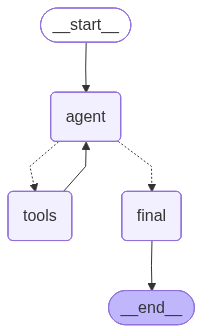

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 8. 테스트 질문 3개 실행

과제 요구사항: 테스트 질문 3개 이상.

1. **도구 1개 호출**: "운동화 뭐 있어?"
2. **도구 여러 개 + 멀티턴**: "아디다스 삼바 270 재고 있어? 사이즈 가이드도 알려줘"
3. **도구 호출 X**: "안녕!"  ← ReAct가 제대로 동작하면 도구 호출 안 해야 함

In [10]:
from langchain_core.messages import HumanMessage


def run_test(question: str):
    print("=" * 70)
    print(f"❓ 질문: {question}")
    print("=" * 70)
    
    result = graph.invoke({"messages": [HumanMessage(content=question)], "final_response": None})
    
    # tool call trace 출력
    print("\n📋 Tool call trace:")
    for msg in result["messages"]:
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"  🔧 {tc['name']}({tc['args']})")
        elif msg.type == "tool":
            content = str(msg.content)[:150]
            print(f"  ↩️  결과: {content}")
    
    # 최종 structured 응답
    final = result["final_response"]
    print(f"\n✅ 최종 응답:")
    print(f"  answer: {final.answer}")
    print(f"  reasoning: {final.reasoning}")
    print(f"  tools_used: {final.tools_used}")
    print(f"  confidence: {final.confidence}")
    print()

In [11]:
run_test("운동화 뭐 있어?")

❓ 질문: 운동화 뭐 있어?

📋 Tool call trace:
  🔧 search_products({'query': '운동화'})
  ↩️  결과: [{"message": "'운동화'에 대한 검색 결과가 없습니다."}]

✅ 최종 응답:
  answer: 죄송하지만, 현재 운동화에 대한 검색 결과가 없습니다. 다른 종류의 상품이나 다른 키워드로 검색해보실 수 있어요. 어떤 것을 찾고 계신지 알려주시면 도와드리겠습니다!
  reasoning: 운동화에 대한 검색 결과가 없어서 대신 다른 추천을 드려야 합니다.
  tools_used: ['search_products']
  confidence: 0.85



In [12]:
run_test("아디다스 삼바 P001 상세 알려주고, 사이즈 어떻게 골라야 하는지도 가르쳐줘")

❓ 질문: 아디다스 삼바 P001 상세 알려주고, 사이즈 어떻게 골라야 하는지도 가르쳐줘

📋 Tool call trace:
  🔧 get_product_detail({'product_id': 'P001'})
  🔧 get_size_guide({'category': 'sneakers'})
  ↩️  결과: {"id": "P001", "name": "아디다스 삼바 OG 블랙", "price": 139000, "category": "sneakers", "sizes": [240, 250, 260, 270, 280], "stock": 12}
  ↩️  결과: 운동화는 평소 발 길이(mm) + 5~10mm 권장. 아디다스는 살짝 크게, 컨버스는 정사이즈.

✅ 최종 응답:
  answer: 아디다스 삼바 OG 블랙에 대한 상세 정보는 아래와 같습니다:

- **상품명**: 아디다스 삼바 OG 블랙
- **가격**: 139,000원
- **카테고리**: 스니커즈
- **가능한 사이즈**: 240, 250, 260, 270, 280
- **재고**: 12개

사이즈 선택에 관한 안내는 다음과 같습니다:
운동화는 일반적으로 발 길이에 5~10mm를 더하여 선택하는 것이 좋습니다. 아디다스 브랜드는 다른 브랜드보다 약간 크게 나오는 경향이 있으니 이 점을 참고하시기 바랍니다. 

도움이 필요하시면 언제든지 말씀해 주세요!
  reasoning: 사용자가 아디다스 삼바 P001의 상세 정보를 알고 싶어 했으며, 사이즈 선택 방법에 대해서도 요청하였습니다. 이 정보를 제공하기 위해 상품 상세와 사이즈 가이드를 가져왔습니다.
  tools_used: ['get_product_detail', 'get_size_guide']
  confidence: 0.9



In [13]:
run_test("안녕! 너 뭐 할 줄 알아?")

❓ 질문: 안녕! 너 뭐 할 줄 알아?

📋 Tool call trace:

✅ 최종 응답:
  answer: 안녕하세요! 제가 상품 검색, 상세 조회, 사이즈 가이드를 도와드릴 수 있어요. 어떤 정보가 필요하신가요?
  reasoning: 사용자가 필요한 정보를 요청할 수 있도록 기본적인 소개 및 지원 가능 항목을 명확히 했습니다.
  tools_used: []
  confidence: 0.5



## 9. (심화) 추가 테스트 — 존재하지 않는 상품

도구 실패 케이스도 ReAct 루프가 잘 처리하는지 확인.

In [14]:
run_test("P999 상품 정보 좀 알려줘")

❓ 질문: P999 상품 정보 좀 알려줘

📋 Tool call trace:
  🔧 get_product_detail({'product_id': 'P999'})
  ↩️  결과: {"error": "상품 P999를 찾을 수 없습니다."}

✅ 최종 응답:
  answer: 죄송하지만, "P999" 상품을 찾을 수 없습니다. 올바른 상품 ID를 확인해주시거나 다른 상품에 대한 질문이 있으시면 말씀해 주세요!
  reasoning: 주어진 상품 ID인 'P999'에 대한 정보 요청을 했지만, 시스템에서 해당 상품을 찾을 수 없는 오류가 발생했습니다. 따라서 사용자가 다른 요청을 하도록 유도하는 메시지를 제공하는 것이 적절합니다.
  tools_used: ['get_product_detail']
  confidence: 0.85



## 정리

**과제 체크리스트:**
- [x] StateGraph로 직접 그래프 구성 (`create_agent` 사용 안 함)
- [x] 도메인용 tool 3개 (`search_products`, `get_product_detail`, `get_size_guide`)
- [x] 조건부 엣지로 tool 호출 여부 제어 (`should_continue`)
- [x] Pydantic structured output (`ShoppingResponse`: answer, reasoning, tools_used, confidence)
- [x] 그래프 시각화
- [x] 테스트 질문 3개 이상 실행
- [x] tool call trace 출력 (심화)
- [x] 응답 스키마에 reasoning, tools_used, confidence 포함 (심화)